# 目标
1. 验证`LiteCue-Net`是否能够正常加载数据
2. 验证采样策略
3. 可视化 Tensor 形状与归一化后的图像

## 1. 环境设置
导入必要的环境依赖，设置项目路径

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# 将项目的根目录添加到路径中，确保能导入 src
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.dataset import LiteCueDataset
from src.data.transforms import get_transforms

# 设置 matplotlib 显示属性
%matplotlib inline
plt.rcParams['figure.figsize'] = (20, 10)

print(f"Project root: {project_root}")


Project root: d:\01_Lab\Project\LiteCue-Net


## 2. 初始化数据集
首先确认 `data/dataset_index.pkl`和`data/clips`路径正确

In [2]:
# 配置路径
INDEX_PATH = os.path.join(project_root, 'data/dataset_index.pkl')
DATA_PATH = os.path.join(project_root, 'data/clips')

# 初始化
# 使用 'val' 模式以获得确定性的中心采样（Center Sampling），方便观察
dataset = LiteCueDataset(
    index_path=INDEX_PATH,
    data_root=DATA_PATH,
    mode='val',
    clip_len=4,
    clip_num=16,
    transforms=get_transforms(mode='val')
)

print(f"数据集大小: {len(dataset)} 样本")


Loading dataset index from d:\01_Lab\Project\LiteCue-Net\data/dataset_index.pkl...
数据集大小: 12529 样本


## 3. 核心功能：反归一化与可视化工具
- 模型输出的 Tensor 经过了 ImageNet 的均值方差归一化，直接画图会是一片黑或怪异的颜色。
- 需要 `denormalize` 函数将其还原为人类可读的 RGB 图像。

In [3]:
def denormalize(tensor):
    """ 
    反归一化：(Tensor) -> NumPy 数组
    x = z * std + mean
    """
    # ImageNet 的均值和标准差
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

def visualize_sample(video_tensor, label, video_id):
    """ 
    可视化一个视频样本的采样结果 
    video_tensor shape: (M, K, C, H, W) —> (16, 4, 3, 224, 224)
    """
    M, K, C, H, W = video_tensor.shape
    print(f"Video ID: {video_id} | Label: {'Fake' if label == 1 else 'Real'}")
    print(f"Video tensor shape: {video_tensor.shape} (M={M}, K={K}, C={C}, H={H}, W={W})")

    clips_to_show = [0,5,10,15] 

    # 准备画板
    fig, axes = plt.subplots(len(clips_to_show), K, figsize=(12, 10))
    fig.suptitle(f"Sampling Check: Video {video_id} ({'Fake' if label == 1 else 'Real'})", fontsize=16)

    for i, clip_idx in enumerate(clips_to_show):
        # 获取当前 Clip 的4帧
        clip_data = video_tensor[clip_idx]  # shape: (K, C, H, W)

        # 反归一化
        clip_rgb = denormalize(clip_data)  # shape: (K, C, H, W)

        for frame_idx in range(K):
            ax = axes[i, frame_idx]
            img_np = clip_rgb[frame_idx].permute(1, 2, 0).numpy()  # (H, W, C)
            ax.imshow(img_np)
            ax.axis('off')
            
            if frame_idx == 0:
                ax.set_title(f"Clip {clip_idx}\nSegment Start", fontsize=10, color='blue', loc='left') 
            else:
                ax.set_title(f"Frame {frame_idx}", fontsize=10)

    plt.tight_layout()
    plt.show()

## 4. 运行检查

观察重点：
1. **行内 (Intra-Clip)**: 同一行的 4 张图应该是**极度相似、连贯**的（比如嘴唇微张的过程）。验证 `LiteCueDataset` 正确读取了连续帧。
2. **行间 (Inter-Clip)**: 不同行的图片应该有明显的**时间跨度**（比如头部姿态变化、表情变化）。验证 `sampler` 覆盖了视频全局。

Video ID: 844_797 | Label: Fake
Video tensor shape: torch.Size([16, 4, 3, 224, 224]) (M=16, K=4, C=3, H=224, W=224)


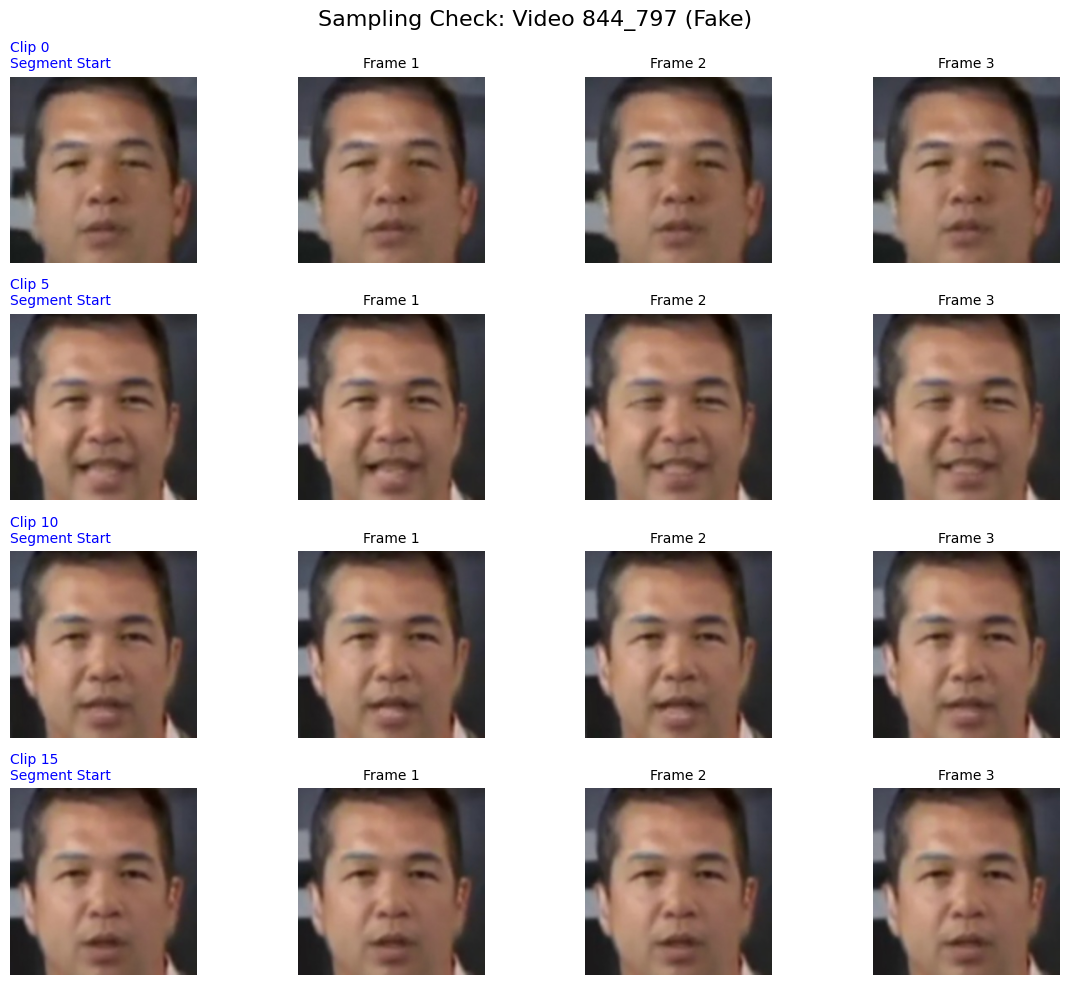

In [9]:
# 随机抽取一个样本进行可视化
idx = np.random.randint(0, len(dataset))
# 或者指定
# idx = 10

video_tensor, label = dataset[idx]  # 获取样本

# 获取 Video ID 方便核对
video_id = dataset.data[idx]['video_id']

visualize_sample(video_tensor, label, video_id)
